# Inference Performance Comparison of ProPicker on the UMU Synthetic Thyroglobulin Dataset

This notebook evaluates and compares **inference-time particle picking performance** of the original pretrained **ProPicker** checkpoint and a **thyroglobulin-adapted model** on the **UMU synthetic dataset**.


In [1]:
import sys
from pathlib import Path

# Add project root and experiments to path
PROJECT_ROOT = Path("../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

# Import paths (file system locations)
from paths import (
    UMU_SYNTH_DIR,
    UMU_SYNTH_TOMOS_DIR,
    UMU_SYNTH_CSV,
    TOMOTWIN_MODEL_FILE,
    PROPICKER_TOOLS_DIR,
    EXP2_RESULTS_DIR,
    EXP2_FINETUNING_DIR,
    EXP2_DATA_DIR,
    EXP2_COORDS_DIR,
)

# Import config (experiment parameters and utilities)
from experiments.config import (
    setup_propicker_paths,
    THYROGLOBULIN_NAME,
    THYROGLOBULIN_LABEL,
    PROMPT_SIZE,
    PROMPT_HALF,
    THYROGLOBULIN_DIAMETER,
    LABEL_DIAMETER,
)

# Setup ProPicker imports
PROPICKER_DIR = setup_propicker_paths()

# Alias for compatibility with the rest of the notebook
PARTICLE_TYPE = THYROGLOBULIN_NAME
EXP_RESULTS_DIR = EXP2_RESULTS_DIR
FINETUNING_DIR = EXP2_FINETUNING_DIR
DATA_DIR = EXP2_DATA_DIR
COORDS_DIR = EXP2_COORDS_DIR

# Create directories if they don't exist
EXP_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FINETUNING_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
COORDS_DIR.mkdir(parents=True, exist_ok=True)

import subprocess
import pandas as pd
import numpy as np
import torch
from matplotlib import pyplot as plt

from inference.tomotwin import get_tomotwin_prompt_embeds_dict
from utils.mrctools import load_mrc_data

import warnings
warnings.filterwarnings("ignore")

print(f"ProPicker tools: {PROPICKER_DIR}")
print(f"UMU Synth data: {UMU_SYNTH_DIR}")
print(f"Tomograms dir: {UMU_SYNTH_TOMOS_DIR}")
print(f"TomoTwin model: {TOMOTWIN_MODEL_FILE}")
print(f"Results dir: {EXP_RESULTS_DIR}")
print(f"\nThyroglobulin parameters:")
print(f"  Particle type: {PARTICLE_TYPE}")
print(f"  Label in CSV: {THYROGLOBULIN_LABEL}")
print(f"  Prompt size: {PROMPT_SIZE}×{PROMPT_SIZE}×{PROMPT_SIZE}")
print(f"  Diameter: {THYROGLOBULIN_DIAMETER}")

ProPicker tools: /home/carloshg/Dev/cryoet-particle-picking/tools/ProPicker/propicker
UMU Synth data: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth
Tomograms dir: /home/carloshg/Dev/cryoet-particle-picking/data/umu_synth/tomos
TomoTwin model: /home/carloshg/Dev/cryoet-particle-picking/models/tomotwin.pth
Results dir: /home/carloshg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy

Thyroglobulin parameters:
  Particle type: thyroglobulin
  Label in CSV: 7
  Prompt size: 37×37×37
  Diameter: 30


## Step 1: Test Fine-Tuned Model

After fine-tuning completes, you can run inference using the inference script:

```bash
cd /home/carlos-hg/Dev/cryoet-particle-picking/tools/ProPicker
python ../../experiments/exp2_umusynth_thy/scripts/umusynth_inference.py
```

The inference script will:
1. Automatically find the best checkpoint from training
2. Run inference on the validation tomograms
3. Save results to the test directory

In [2]:
# Check for training results
import glob

FINETUNING_DEEPETPICKER_DIR = PROJECT_ROOT / "results" / "exp2_umusynth_thy" / "fine_tuning_deepetpicker"

print("=" * 70)
print("CHECKING FINE-TUNING RESULTS")
print("=" * 70)

if FINETUNING_DEEPETPICKER_DIR.exists():
    print(f"\n✅ Fine-tuning directory exists: {FINETUNING_DEEPETPICKER_DIR}")
    
    # Check for runs directory
    runs_dir = FINETUNING_DEEPETPICKER_DIR / "runs" / "train"
    if runs_dir.exists():
        # Find checkpoint files
        ckpt_files = list(runs_dir.glob("*/version_*/checkpoints/*.ckpt"))
        if ckpt_files:
            print(f"\n📁 Found {len(ckpt_files)} checkpoint(s):")
            for ckpt in sorted(ckpt_files)[-3:]:  # Show last 3
                print(f"   {ckpt.name}")
            best_ckpt = sorted(ckpt_files, key=lambda x: x.stat().st_mtime)[-1]
            print(f"\n🏆 Latest checkpoint: {best_ckpt}")
        else:
            print("\n⏳ No checkpoints found yet. Run fine-tuning first!")
            best_ckpt = None
    else:
        print(f"\n⏳ Training not started yet. Run the fine-tuning script!")
        best_ckpt = None
        
    # Check for configs
    configs_dir = FINETUNING_DEEPETPICKER_DIR / "configs"
    if configs_dir.exists():
        config_files = list(configs_dir.glob("*.py"))
        print(f"\n📋 Config files: {[f.name for f in config_files]}")
else:
    print(f"\n⏳ Fine-tuning directory not created yet.")
    print(f"   Run: python umusynth_fine_tuning.py")
    best_ckpt = None

CHECKING FINE-TUNING RESULTS

✅ Fine-tuning directory exists: /home/carloshg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/fine_tuning_deepetpicker

📁 Found 1 checkpoint(s):
   epoch=18-step=26504.ckpt

🏆 Latest checkpoint: /home/carloshg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/fine_tuning_deepetpicker/runs/train/train_ProPicker_BlockSize72_CELoss_MaxEpoch20_bs2_lr0.001_IP1_bg1_coord1_Softmax0_bn__TNNone/version_0/checkpoints/epoch=18-step=26504.ckpt

📋 Config files: ['train.py', 'test.py', 'preprocess_test.py', 'preprocess.py']


In [3]:
# After running inference with the script, check the results
test_dir = FINETUNING_DEEPETPICKER_DIR / "test"

print("=" * 70)
print("CHECKING INFERENCE RESULTS")
print("=" * 70)

if test_dir.exists():
    print(f"\n✅ Test directory exists: {test_dir}")
    
    # Check for preprocessed tomograms
    data_std_dir = test_dir / "data_std"
    if data_std_dir.exists():
        pred_files = list(data_std_dir.glob("*.mrc"))
        print(f"\n📊 Preprocessed tomograms: {len(pred_files)}")
        
    # Check for segmentation output (localization maps as .pt files)
    seg_output_dir = test_dir / "full_segmentation_output"
    if seg_output_dir.exists():
        locmap_files = list(seg_output_dir.glob("*.pt"))
        print(f"\n📁 Segmentation output: {seg_output_dir}")
        print(f"   .pt localization maps: {len(locmap_files)}")
        for f in sorted(locmap_files):
            print(f"      - {f.name}")
    else:
        print("\n⏳ No segmentation output found (full_segmentation_output/)")
    
    # Check for predicted coordinates
    pred_labels_dir = test_dir / "PredictedLabels"
    if pred_labels_dir.exists():
        print(f"\n📁 Predicted Labels: {pred_labels_dir}")
        
        coords_all = pred_labels_dir / "Coords_All"
        coords_area = pred_labels_dir / "Coords_withArea"
        
        if coords_all.exists():
            coord_files = list(coords_all.glob("*.coords"))
            print(f"   Coords_All: {len(coord_files)} files")
        if coords_area.exists():
            coord_files = list(coords_area.glob("*.coords"))
            print(f"   Coords_withArea: {len(coord_files)} files")
    else:
        print("\n⏳ No predicted labels found (PredictedLabels/)")
        
else:
    print(f"\n⏳ Test directory not found.")
    print(f"   Run: python umusynth_inference.py")

CHECKING INFERENCE RESULTS

✅ Test directory exists: /home/carloshg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/fine_tuning_deepetpicker/test

📊 Preprocessed tomograms: 5

📁 Segmentation output: /home/carloshg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/fine_tuning_deepetpicker/test/full_segmentation_output
   .pt localization maps: 5
      - tomo_rec_5_snr1.66.pt
      - tomo_rec_6_snr1.17.pt
      - tomo_rec_7_snr1.13.pt
      - tomo_rec_8_snr0.57.pt
      - tomo_rec_9_snr1.28.pt

📁 Predicted Labels: /home/carloshg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/fine_tuning_deepetpicker/test/PredictedLabels
   Coords_All: 5 files
   Coords_withArea: 5 files


Loading localization map for: tomo_rec_5_snr1.66
Localization map shape: (196, 642, 642)
Localization map range: [0.0000, 1.0000]


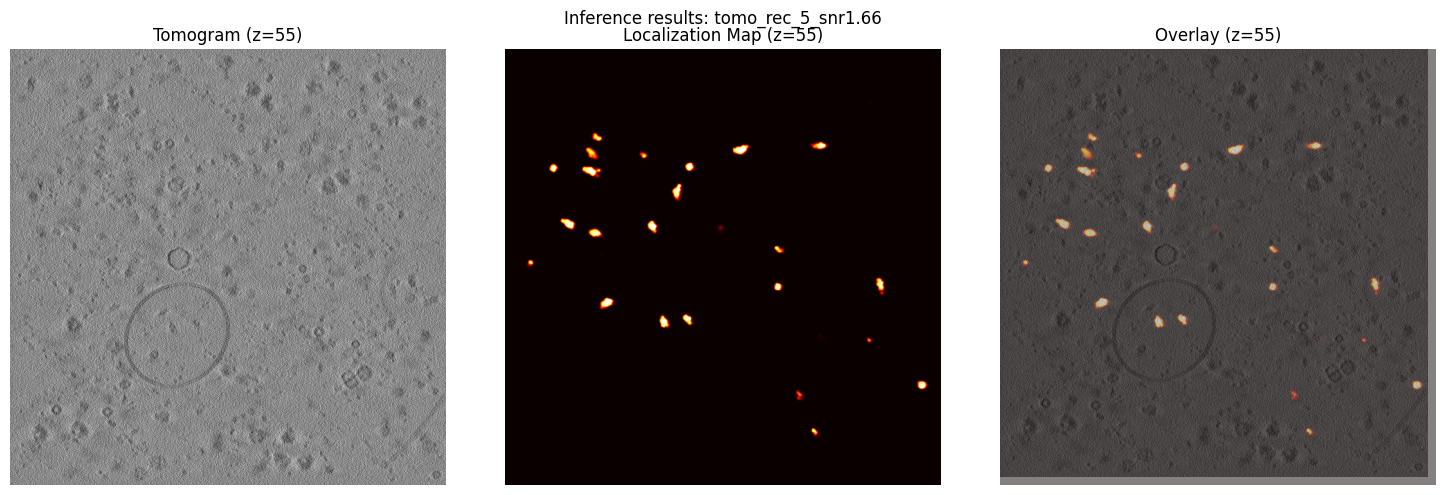

In [4]:
# Load and visualize prediction results (localization maps)
import torch

test_dir = FINETUNING_DEEPETPICKER_DIR / "test"
seg_output_dir = test_dir / "full_segmentation_output" if test_dir.exists() else None

if seg_output_dir and seg_output_dir.exists():
    locmap_files = sorted(seg_output_dir.glob("*.pt"))
    
    if locmap_files:
        # Load a localization map file
        locmap_file = locmap_files[0]
        tomo_name = locmap_file.stem
        
        print(f"Loading localization map for: {tomo_name}")
        
        # Load the .pt file
        locmap_data = torch.load(locmap_file, weights_only=False)
        
        # Handle different possible formats
        if isinstance(locmap_data, dict):
            print(f"Keys in file: {list(locmap_data.keys())}")
            # Try common keys
            if 'segmentation' in locmap_data:
                pred_locmap = locmap_data['segmentation'].numpy()
            elif 'data' in locmap_data:
                pred_locmap = locmap_data['data'].numpy()
            else:
                # Use first tensor value
                pred_locmap = list(locmap_data.values())[0]
                if hasattr(pred_locmap, 'numpy'):
                    pred_locmap = pred_locmap.numpy()
        elif hasattr(locmap_data, 'numpy'):
            pred_locmap = locmap_data.numpy()
        else:
            pred_locmap = locmap_data
            
        print(f"Localization map shape: {pred_locmap.shape}")
        print(f"Localization map range: [{pred_locmap.min():.4f}, {pred_locmap.max():.4f}]")
        
        # Load corresponding tomogram
        tomo_file = UMU_SYNTH_TOMOS_DIR / f"{tomo_name}.mrc"
        if tomo_file.exists():
            tomo = load_mrc_data(str(tomo_file)).numpy()
            
            # Visualize
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Find slice with predictions
            if len(pred_locmap.shape) == 4:
                # Shape is (C, D, H, W), take channel 1 (foreground) if available
                if pred_locmap.shape[0] > 1:
                    pred_locmap = pred_locmap[1]  # Foreground channel
                else:
                    pred_locmap = pred_locmap[0]
            
            pred_sum = pred_locmap.sum(axis=(1, 2))
            if pred_sum.max() > 0:
                mid_z = int(np.argmax(pred_sum))
            else:
                mid_z = pred_locmap.shape[0] // 2
            
            # Tomogram
            axes[0].imshow(tomo[mid_z], cmap='gray')
            axes[0].set_title(f'Tomogram (z={mid_z})')
            axes[0].axis('off')
            
            # Prediction
            axes[1].imshow(pred_locmap[mid_z], cmap='hot')
            axes[1].set_title(f'Localization Map (z={mid_z})')
            axes[1].axis('off')
            
            # Overlay
            axes[2].imshow(tomo[mid_z], cmap='gray')
            axes[2].imshow(pred_locmap[mid_z], cmap='hot', alpha=0.5)
            axes[2].set_title(f'Overlay (z={mid_z})')
            axes[2].axis('off')
            
            plt.suptitle(f"Inference results: {tomo_name}")
            plt.tight_layout()
            plt.show()
        else:
            print(f"⚠️ Tomogram not found: {tomo_file}")
    else:
        print("⚠️ No localization map files found in segmentation output")
else:
    print("⚠️ No results yet. Run fine-tuning and inference scripts first!")

### Evaluation

Evaluate the fine-tuned model's performance by comparing predicted particle positions with ground truth.

In [5]:
# Evaluate predictions using predicted coordinates from PredictedLabels
import torch
from scipy import ndimage
from scipy.spatial.distance import cdist

test_dir = FINETUNING_DEEPETPICKER_DIR / "test"
seg_output_dir = test_dir / "full_segmentation_output" if test_dir.exists() else None
pred_labels_dir = test_dir / "PredictedLabels" if test_dir.exists() else None

# Check if we have prediction results
has_locmaps = seg_output_dir and seg_output_dir.exists() and list(seg_output_dir.glob("*.pt"))
has_coords = pred_labels_dir and (pred_labels_dir / "Coords_All").exists() and list((pred_labels_dir / "Coords_All").glob("*.coords"))

if has_locmaps or has_coords:
    print("=" * 70)
    print("EVALUATION OF PREDICTIONS")
    print("=" * 70)
    
    all_results = []
    
    # Get list of test tomograms
    if has_coords:
        coords_all_dir = pred_labels_dir / "Coords_All"
        coord_files = sorted(coords_all_dir.glob("*.coords"))
        tomo_names = [f.stem for f in coord_files]
    elif has_locmaps:
        locmap_files = sorted(seg_output_dir.glob("*.pt"))
        tomo_names = [f.stem for f in locmap_files]
    
    for tomo_name in tomo_names:
        # Get ground truth coordinates
        coord_file = COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
        if not coord_file.exists():
            print(f"⚠️ No ground truth coords for {tomo_name}")
            continue
            
        gt_df = pd.read_csv(coord_file)
        gt_coords = gt_df[['X', 'Y', 'Z']].values
        
        # Get predicted coordinates from .coords file (tab-separated, no header)
        if has_coords:
            pred_coord_file = pred_labels_dir / "Coords_All" / f"{tomo_name}.coords"
            if pred_coord_file.exists():
                pred_df = pd.read_csv(pred_coord_file, sep='\t', header=None, names=['X', 'Y', 'Z'])
                pred_coords = pred_df[['X', 'Y', 'Z']].values
            else:
                pred_coords = np.array([]).reshape(0, 3)
        else:
            # Extract from localization map using clustering
            locmap_file = seg_output_dir / f"{tomo_name}.pt"
            locmap_data = torch.load(locmap_file, weights_only=False)
            
            # Handle different formats
            if isinstance(locmap_data, dict):
                pred_locmap = list(locmap_data.values())[0]
                if hasattr(pred_locmap, 'numpy'):
                    pred_locmap = pred_locmap.numpy()
            elif hasattr(locmap_data, 'numpy'):
                pred_locmap = locmap_data.numpy()
            else:
                pred_locmap = locmap_data
                
            # Handle 4D (C, D, H, W) format
            if len(pred_locmap.shape) == 4:
                if pred_locmap.shape[0] > 1:
                    pred_locmap = pred_locmap[1]  # Foreground channel
                else:
                    pred_locmap = pred_locmap[0]
            
            # Binarization and clustering
            binarization_thresh = 0.5
            binary_locmap = pred_locmap > binarization_thresh
            labeled_array, num_features = ndimage.label(binary_locmap)
            
            if num_features > 0:
                centroids = ndimage.center_of_mass(binary_locmap, labeled_array, range(1, num_features + 1))
                pred_coords = np.array(centroids)[:, ::-1]  # Convert (Z, Y, X) to (X, Y, Z)
            else:
                pred_coords = np.array([]).reshape(0, 3)
        
        # Calculate metrics
        n_gt = len(gt_coords)
        n_pred = len(pred_coords)
        
        # Match predictions to ground truth using distance threshold
        distance_thresh = PROMPT_SIZE / 2  # Half the prompt size
        matched_gt = set()
        matched_pred = set()
        
        if n_pred > 0 and n_gt > 0:
            distances = cdist(pred_coords, gt_coords)
            
            for i in range(len(pred_coords)):
                min_dist_idx = np.argmin(distances[i])
                if distances[i, min_dist_idx] < distance_thresh and min_dist_idx not in matched_gt:
                    matched_gt.add(min_dist_idx)
                    matched_pred.add(i)
        
        tp = len(matched_gt)
        fp = n_pred - tp
        fn = n_gt - tp
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        print(f"\n{tomo_name}:")
        print(f"  GT particles: {n_gt}, Predicted: {n_pred}")
        print(f"  TP: {tp}, FP: {fp}, FN: {fn}")
        print(f"  Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")
        
        all_results.append({
            'tomo': tomo_name,
            'n_gt': n_gt,
            'n_pred': n_pred,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'precision': precision,
            'recall': recall,
            'f1': f1
        })
    
    # Summary
    if all_results:
        results_df = pd.DataFrame(all_results)
        print("\n" + "=" * 70)
        print("SUMMARY")
        print("=" * 70)
        print(f"Mean Precision: {results_df['precision'].mean():.3f}")
        print(f"Mean Recall: {results_df['recall'].mean():.3f}")
        print(f"Mean F1: {results_df['f1'].mean():.3f}")
else:
    print("⚠️ Run fine-tuning and inference scripts first!")
    print(f"   Expected outputs in: {test_dir}")

EVALUATION OF PREDICTIONS

tomo_rec_5_snr1.66:
  GT particles: 127, Predicted: 142
  TP: 127, FP: 15, FN: 0
  Precision: 0.894, Recall: 1.000, F1: 0.944

tomo_rec_6_snr1.17:
  GT particles: 120, Predicted: 133
  TP: 119, FP: 14, FN: 1
  Precision: 0.895, Recall: 0.992, F1: 0.941

tomo_rec_7_snr1.13:
  GT particles: 133, Predicted: 151
  TP: 131, FP: 20, FN: 2
  Precision: 0.868, Recall: 0.985, F1: 0.923

tomo_rec_8_snr0.57:
  GT particles: 115, Predicted: 191
  TP: 108, FP: 83, FN: 7
  Precision: 0.565, Recall: 0.939, F1: 0.706

tomo_rec_9_snr1.28:
  GT particles: 127, Predicted: 143
  TP: 127, FP: 16, FN: 0
  Precision: 0.888, Recall: 1.000, F1: 0.941

SUMMARY
Mean Precision: 0.822
Mean Recall: 0.983
Mean F1: 0.891


## Step 2: Test Baseline Model

In [3]:
# After running inference with the script, check the results
FINETUNING_DEEPETPICKER_DIR = PROJECT_ROOT / "results" / "exp2_umusynth_thy" / "fine_tuning_deepetpicker"
test_dir = FINETUNING_DEEPETPICKER_DIR / "test"

print("=" * 70)
print("CHECKING INFERENCE RESULTS")
print("=" * 70)

if test_dir.exists():
    print(f"\n✅ Test directory exists: {test_dir}")
    
    # Check for preprocessed tomograms
    data_std_dir = test_dir / "data_std"
    if data_std_dir.exists():
        pred_files = list(data_std_dir.glob("*.mrc"))
        print(f"\n📊 Preprocessed tomograms: {len(pred_files)}")
        
    # Check for segmentation output (localization maps as .pt files)
    seg_output_dir = test_dir / "full_segmentation_output"
    if seg_output_dir.exists():
        locmap_files = list(seg_output_dir.glob("*.pt"))
        print(f"\n📁 Segmentation output: {seg_output_dir}")
        print(f"   .pt localization maps: {len(locmap_files)}")
        for f in sorted(locmap_files):
            print(f"      - {f.name}")
    else:
        print("\n⏳ No segmentation output found (full_segmentation_output/)")
    
    # Check for predicted coordinates
    pred_labels_dir = test_dir / "PredictedLabels"
    if pred_labels_dir.exists():
        print(f"\n📁 Predicted Labels: {pred_labels_dir}")
        
        coords_all = pred_labels_dir / "Coords_All"
        coords_area = pred_labels_dir / "Coords_withArea"
        
        if coords_all.exists():
            coord_files = list(coords_all.glob("*.coords"))
            print(f"   Coords_All: {len(coord_files)} files")
        if coords_area.exists():
            coord_files = list(coords_area.glob("*.coords"))
            print(f"   Coords_withArea: {len(coord_files)} files")
    else:
        print("\n⏳ No predicted labels found (PredictedLabels/)")
        
else:
    print(f"\n⏳ Test directory not found.")
    print(f"   Run: python umusynth_inference.py")

CHECKING INFERENCE RESULTS

✅ Test directory exists: /home/carloshg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/fine_tuning_deepetpicker/test

📁 Segmentation output: /home/carloshg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/fine_tuning_deepetpicker/test/full_segmentation_output
   .pt localization maps: 5
      - tomo_rec_5_snr1.66.pt
      - tomo_rec_6_snr1.17.pt
      - tomo_rec_7_snr1.13.pt
      - tomo_rec_8_snr0.57.pt
      - tomo_rec_9_snr1.28.pt

📁 Predicted Labels: /home/carloshg/Dev/cryoet-particle-picking/results/exp2_umusynth_thy/fine_tuning_deepetpicker/test/PredictedLabels
   Coords_All: 5 files
   Coords_withArea: 5 files


Loading localization map for: tomo_rec_5_snr1.66
Localization map shape: (196, 642, 642)
Localization map range: [0.0000, 0.8737]


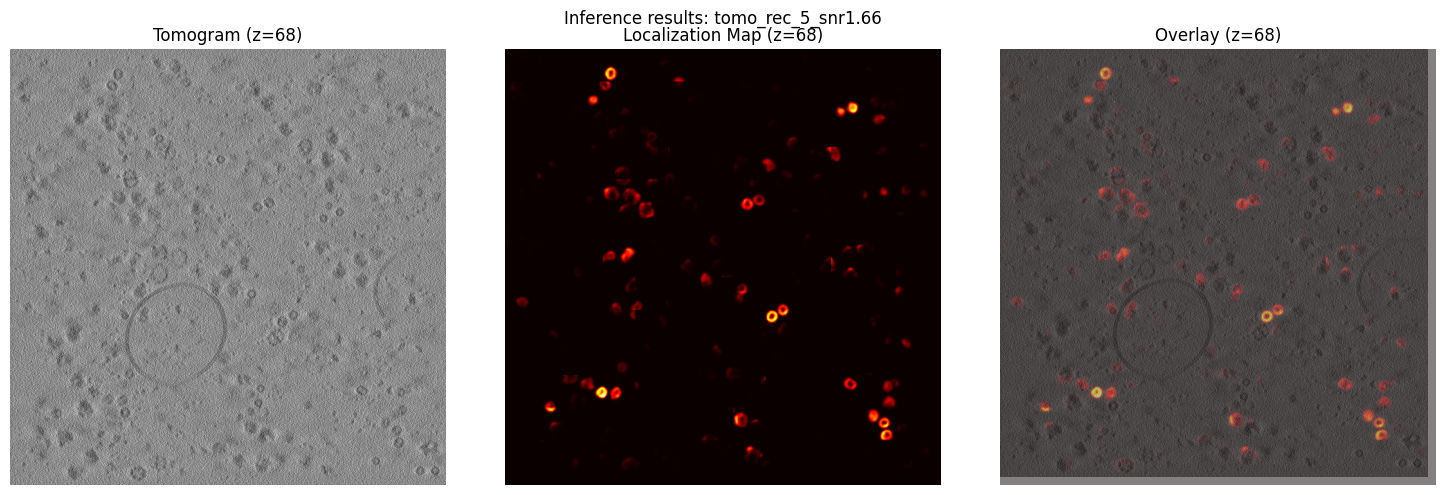

In [4]:
# Load and visualize prediction results (localization maps)
import torch

test_dir = FINETUNING_DEEPETPICKER_DIR / "test"
seg_output_dir = test_dir / "full_segmentation_output" if test_dir.exists() else None

if seg_output_dir and seg_output_dir.exists():
    locmap_files = sorted(seg_output_dir.glob("*.pt"))
    
    if locmap_files:
        # Load a localization map file
        locmap_file = locmap_files[0]
        tomo_name = locmap_file.stem
        
        print(f"Loading localization map for: {tomo_name}")
        
        # Load the .pt file
        locmap_data = torch.load(locmap_file, weights_only=False)
        
        # Handle different possible formats
        if isinstance(locmap_data, dict):
            print(f"Keys in file: {list(locmap_data.keys())}")
            # Try common keys
            if 'segmentation' in locmap_data:
                pred_locmap = locmap_data['segmentation'].numpy()
            elif 'data' in locmap_data:
                pred_locmap = locmap_data['data'].numpy()
            else:
                # Use first tensor value
                pred_locmap = list(locmap_data.values())[0]
                if hasattr(pred_locmap, 'numpy'):
                    pred_locmap = pred_locmap.numpy()
        elif hasattr(locmap_data, 'numpy'):
            pred_locmap = locmap_data.numpy()
        else:
            pred_locmap = locmap_data
            
        print(f"Localization map shape: {pred_locmap.shape}")
        print(f"Localization map range: [{pred_locmap.min():.4f}, {pred_locmap.max():.4f}]")
        
        # Load corresponding tomogram
        tomo_file = UMU_SYNTH_TOMOS_DIR / f"{tomo_name}.mrc"
        if tomo_file.exists():
            tomo = load_mrc_data(str(tomo_file)).numpy()
            
            # Visualize
            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            
            # Find slice with predictions
            if len(pred_locmap.shape) == 4:
                # Shape is (C, D, H, W), take channel 1 (foreground) if available
                if pred_locmap.shape[0] > 1:
                    pred_locmap = pred_locmap[1]  # Foreground channel
                else:
                    pred_locmap = pred_locmap[0]
            
            pred_sum = pred_locmap.sum(axis=(1, 2))
            if pred_sum.max() > 0:
                mid_z = int(np.argmax(pred_sum))
            else:
                mid_z = pred_locmap.shape[0] // 2
            
            # Tomogram
            axes[0].imshow(tomo[mid_z], cmap='gray')
            axes[0].set_title(f'Tomogram (z={mid_z})')
            axes[0].axis('off')
            
            # Prediction
            axes[1].imshow(pred_locmap[mid_z], cmap='hot')
            axes[1].set_title(f'Localization Map (z={mid_z})')
            axes[1].axis('off')
            
            # Overlay
            axes[2].imshow(tomo[mid_z], cmap='gray')
            axes[2].imshow(pred_locmap[mid_z], cmap='hot', alpha=0.5)
            axes[2].set_title(f'Overlay (z={mid_z})')
            axes[2].axis('off')
            
            plt.suptitle(f"Inference results: {tomo_name}")
            plt.tight_layout()
            plt.show()
        else:
            print(f"⚠️ Tomogram not found: {tomo_file}")
    else:
        print("⚠️ No localization map files found in segmentation output")
else:
    print("⚠️ No results yet. Run fine-tuning and inference scripts first!")

In [5]:
# Evaluate predictions using predicted coordinates from PredictedLabels
import torch
from scipy import ndimage
from scipy.spatial.distance import cdist

test_dir = FINETUNING_DEEPETPICKER_DIR / "test"
seg_output_dir = test_dir / "full_segmentation_output" if test_dir.exists() else None
pred_labels_dir = test_dir / "PredictedLabels" if test_dir.exists() else None

# Check if we have prediction results
has_locmaps = seg_output_dir and seg_output_dir.exists() and list(seg_output_dir.glob("*.pt"))
has_coords = pred_labels_dir and (pred_labels_dir / "Coords_All").exists() and list((pred_labels_dir / "Coords_All").glob("*.coords"))

if has_locmaps or has_coords:
    print("=" * 70)
    print("EVALUATION OF PREDICTIONS")
    print("=" * 70)
    
    all_results = []
    
    # Get list of test tomograms
    if has_coords:
        coords_all_dir = pred_labels_dir / "Coords_All"
        coord_files = sorted(coords_all_dir.glob("*.coords"))
        tomo_names = [f.stem for f in coord_files]
    elif has_locmaps:
        locmap_files = sorted(seg_output_dir.glob("*.pt"))
        tomo_names = [f.stem for f in locmap_files]
    
    for tomo_name in tomo_names:
        # Get ground truth coordinates
        coord_file = COORDS_DIR / f"{tomo_name}_thyroglobulin_coords.csv"
        if not coord_file.exists():
            print(f"⚠️ No ground truth coords for {tomo_name}")
            continue
            
        gt_df = pd.read_csv(coord_file)
        gt_coords = gt_df[['X', 'Y', 'Z']].values
        
        # Get predicted coordinates from .coords file (tab-separated, no header)
        if has_coords:
            pred_coord_file = pred_labels_dir / "Coords_All" / f"{tomo_name}.coords"
            if pred_coord_file.exists():
                pred_df = pd.read_csv(pred_coord_file, sep='\t', header=None, names=['X', 'Y', 'Z'])
                pred_coords = pred_df[['X', 'Y', 'Z']].values
            else:
                pred_coords = np.array([]).reshape(0, 3)
        else:
            # Extract from localization map using clustering
            locmap_file = seg_output_dir / f"{tomo_name}.pt"
            locmap_data = torch.load(locmap_file, weights_only=False)
            
            # Handle different formats
            if isinstance(locmap_data, dict):
                pred_locmap = list(locmap_data.values())[0]
                if hasattr(pred_locmap, 'numpy'):
                    pred_locmap = pred_locmap.numpy()
            elif hasattr(locmap_data, 'numpy'):
                pred_locmap = locmap_data.numpy()
            else:
                pred_locmap = locmap_data
                
            # Handle 4D (C, D, H, W) format
            if len(pred_locmap.shape) == 4:
                if pred_locmap.shape[0] > 1:
                    pred_locmap = pred_locmap[1]  # Foreground channel
                else:
                    pred_locmap = pred_locmap[0]
            
            # Binarization and clustering
            binarization_thresh = 0.5
            binary_locmap = pred_locmap > binarization_thresh
            labeled_array, num_features = ndimage.label(binary_locmap)
            
            if num_features > 0:
                centroids = ndimage.center_of_mass(binary_locmap, labeled_array, range(1, num_features + 1))
                pred_coords = np.array(centroids)[:, ::-1]  # Convert (Z, Y, X) to (X, Y, Z)
            else:
                pred_coords = np.array([]).reshape(0, 3)
        
        # Calculate metrics
        n_gt = len(gt_coords)
        n_pred = len(pred_coords)
        
        # Match predictions to ground truth using distance threshold
        distance_thresh = PROMPT_SIZE / 2  # Half the prompt size
        matched_gt = set()
        matched_pred = set()
        
        if n_pred > 0 and n_gt > 0:
            distances = cdist(pred_coords, gt_coords)
            
            for i in range(len(pred_coords)):
                min_dist_idx = np.argmin(distances[i])
                if distances[i, min_dist_idx] < distance_thresh and min_dist_idx not in matched_gt:
                    matched_gt.add(min_dist_idx)
                    matched_pred.add(i)
        
        tp = len(matched_gt)
        fp = n_pred - tp
        fn = n_gt - tp
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        print(f"\n{tomo_name}:")
        print(f"  GT particles: {n_gt}, Predicted: {n_pred}")
        print(f"  TP: {tp}, FP: {fp}, FN: {fn}")
        print(f"  Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")
        
        all_results.append({
            'tomo': tomo_name,
            'n_gt': n_gt,
            'n_pred': n_pred,
            'tp': tp,
            'fp': fp,
            'fn': fn,
            'precision': precision,
            'recall': recall,
            'f1': f1
        })
    
    # Summary
    if all_results:
        results_df = pd.DataFrame(all_results)
        print("\n" + "=" * 70)
        print("SUMMARY")
        print("=" * 70)
        print(f"Mean Precision: {results_df['precision'].mean():.3f}")
        print(f"Mean Recall: {results_df['recall'].mean():.3f}")
        print(f"Mean F1: {results_df['f1'].mean():.3f}")
else:
    print("⚠️ Run fine-tuning and inference scripts first!")
    print(f"   Expected outputs in: {test_dir}")

EVALUATION OF PREDICTIONS

tomo_rec_5_snr1.66:
  GT particles: 127, Predicted: 24
  TP: 0, FP: 24, FN: 127
  Precision: 0.000, Recall: 0.000, F1: 0.000

tomo_rec_6_snr1.17:
  GT particles: 120, Predicted: 56
  TP: 0, FP: 56, FN: 120
  Precision: 0.000, Recall: 0.000, F1: 0.000

tomo_rec_7_snr1.13:
  GT particles: 133, Predicted: 71
  TP: 2, FP: 69, FN: 131
  Precision: 0.028, Recall: 0.015, F1: 0.020

tomo_rec_8_snr0.57:
  GT particles: 115, Predicted: 168
  TP: 3, FP: 165, FN: 112
  Precision: 0.018, Recall: 0.026, F1: 0.021

tomo_rec_9_snr1.28:
  GT particles: 127, Predicted: 17
  TP: 0, FP: 17, FN: 127
  Precision: 0.000, Recall: 0.000, F1: 0.000

SUMMARY
Mean Precision: 0.009
Mean Recall: 0.008
Mean F1: 0.008


## Conclusion of the Comparative Evaluation

The results obtained in **Experiment 2** are methodologically consistent and reflect the expected behavior of the evaluated models.

The markedly poor performance observed during inference with the **baseline ProPicker model** does not indicate an implementation or evaluation error. Instead, it is a consequence of the limited generalization capability of prompt-based inference when applied to particles and data distributions that deviate significantly from the model’s pretraining domain. In particular, **thyroglobulin** constitutes a highly challenging target due to its small size, low signal-to-noise ratio, and the pronounced domain shift between the synthetic data used for pretraining and the UMU synthetic dataset. Under these conditions, prompt-based picking fails, resulting in near-zero precision, recall, and F1 scores.

Conversely, the **fine-tuned model** achieves a substantial and stable improvement in performance, thereby confirming the correctness of the preprocessing steps, inference pipeline, and evaluation protocol. The large performance gap between the baseline and the fine-tuned model demonstrates that **particle-specific fine-tuning is essential** for reliable detection in challenging scenarios and cannot be replaced by prompt-based inference alone.

In summary, this experiment validates both the soundness of the experimental setup and the central claim of ProPicker: while prompt-based picking can be effective in favorable conditions, **fine-tuning is required to achieve robust and reliable performance for difficult particles and out-of-distribution data**.